In [4]:
""" Carbon fluxes in Paul's observations """
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *
from scipy.stats import linregress, t
from matplotlib import rcParams

rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16

prefix_list = ['UQ_20231113_4d']
N_list = [1000]
BLOCK = 200
VAR_LIST = ['Tair', 'AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'HR', 'NEE']

In [5]:
def get_obs():
    """ Get the observational slope & value at ambient chamber """
    plot_list = [f'P{p:02g}' for p in chamber_list_complete]

    obs_data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract',
                                        'extract_obs_productivity.csv'), index_col = [0, 1, 2])

    t2m_obs = obs_data.loc[:, 'Tair']
    obs_data = obs_data.loc[:, VAR_LIST]
    # obs_data.columns = VAR_LIST

    collection = pd.DataFrame(np.nan,
                              index = pd.MultiIndex.from_product([VAR_LIST, ['amb', 'elev']]),
                              columns = ['mean', 'slope_std', 'slope', 'slope_std'])
    collection.index.names = ['Variable', 'CO2']

    for varname in VAR_LIST:
        for co2 in ['amb','elev']:
            if co2 == 'amb':
                filt = obs_data.index.get_level_values(0).isin([plot_list[0]] + plot_list[1::2])
            else:
                filt = obs_data.index.get_level_values(0).isin(plot_list[2::2])

            if varname != 'TOTSOMC':    
                obs_temp = obs_data.loc[filt, varname]
                obs_T    = t2m_obs.loc[filt]

                filt2 = ~np.isnan(obs_T) & ~np.isnan(obs_temp)
                obs_temp = obs_temp.values[filt2]
                obs_T = obs_T.values[filt2]


                res = linregress(obs_T, obs_temp)

                ts = abs(t.ppf(0.05, len(obs_T) - 2))

                collection.loc[(varname, co2), 'slope'] = res.slope
                collection.loc[(varname, co2), 'slope_std'] = ts * res.stderr

                # use the average of all the chambers to be compatible with simulated results
                # obs_temp = obs_data.loc[obs_data.index.get_level_values(0) == plot_list[0], varname] # T0
                collection.loc[(varname, co2), 'mean'] = obs_temp.mean()
                collection.loc[(varname, co2), 'mean_std'] = obs_temp.std()
            else:
                collection.loc[(varname, co2), 'mean'] = 200000
                collection.loc[(varname, co2), 'slope_std'] = 500000

    return collection

In [6]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, slope_std, slope, ts * slope_std)
collection_sim = {}

for N, prefix in zip(N_list, prefix_list):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :] = np.load(os.path.join(path_out, "extract", prefix, f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # # convert unit from gC m-2 s-1 (per year) to gC m-2 (per year)
    # collect[:, 3:, :, :] = collect[:, 3:, :, :] * 365 * 86400
    # revert the signs of NEE & HR to be compatible with Paul's data
    ## collect[:, -3:-1, :, :] = - collect[:, -3:-1, :, :]

    collection_sim[prefix] = collect

In [7]:
collection_sim[prefix].shape, collection_sim.keys()

((1000, 15, 2, 4), dict_keys(['UQ_20231113_4d']))

In [8]:
# Get the parameters
def get_params(prefix, parname, N, ensemble_members = range(1, 2001)):
#    prefix = 'UQ_20240311'
#    parname = 'kmin_nuptake'
#    N = 2000
    uqroot = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', 'UQ', 
                            f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC')
    N = len(ensemble_members)
    count = 0
    for b in ensemble_members:
        hr = xr.open_dataset( os.path.join(uqroot, f'g{b:05d}', f'clm_params_{b:05d}.nc') )
        parvals = hr[parname].values
        hr.close()
        if count == 0:
            if parvals.shape == ():
                parcollect = np.full([N, 1], np.nan)
            else:
                parcollect = np.full([N, len(parvals)], np.nan)
        if parvals.shape == ():
            parcollect[count, 0] = parvals
        else:
            parcollect[count, :] = parvals.reshape(-1)
        count = count + 1
    return parcollect

In [9]:
collection_obs = get_obs()
collection_obs

mean     slope_std      slope  \
Variable                CO2                                          
Tair                    amb     10.271591  0.000000e+00   1.000000   
                        elev    11.248270  5.325182e-09   1.000000   
AGBiomass_Spruce        amb   1017.021727  1.433042e+01 -20.812852   
                        elev  1056.702388  1.400887e+01 -10.641595   
AGBiomass_Tamarack      amb    279.636238  5.350410e+00   0.956728   
                        elev   254.377602  3.506717e+00   2.845130   
AGBiomass_Shrub         amb    270.340560  1.522393e+01  14.201267   
                        elev   302.026760  1.330122e+01  11.058754   
AGNPPtoBiomass_Spruce   amb      0.085801  3.566904e-03  -0.006844   
                        elev     0.106010  2.475041e-03   0.002045   
AGNPPtoBiomass_Tamarack amb      0.139133  4.632497e-03   0.002246   
                        elev     0.158908  9.326208e-03   0.003056   
AGNPPtoBiomass_Shrub    amb      0.339493  1.372615e-02   0.005989   
                        elev     0.386659  1.104133e-02   0.009616   
AGNPP_Spruce            amb     90.367160  7.372231e+00  -7.412613   
                        elev   108.182080  3.351306e+00  -6.237117   
AGNPP_Tamarack          amb     41.946960  2.009258e+00   0.357145   
                        elev    27.670120  2.033783e+00   1.706969   
AGNPP_Shrub             amb     83.706280  4.000128e+00   4.888405   
                        elev   111.648920  4.166588e+00   7.450332   
NPP_moss                amb     93.539700  3.237914e+00 -10.250541   
                        elev    64.657760  3.995419e+00  -6.800788   
BGNPP_TreeShrub         amb     75.163750  2.220529e+00   6.770230   
                        elev    79.211250  2.957010e+00  10.162000   
BGtoAG_TreeShrub        amb      0.458657  2.308380e-02   0.021313   
                        elev     0.321365  1.159701e-02   0.037774   
HR                      amb   -429.644529  4.317464e+00 -20.084135   
                        elev  -460.730872  4.537966e+00 -22.430646   
NEE                     amb   -174.324416  1.000074e+01 -29.397569   
                        elev  -210.644919  1.012126e+01 -26.863250   

                                 slope_std    mean_std  
Variable                CO2                             
Tair                    amb   0.000000e+00    3.789731  
                        elev  5.325182e-09    3.271975  
AGBiomass_Spruce        amb   1.433042e+01  144.948741  
                        elev  1.400887e+01  132.904337  
AGBiomass_Tamarack      amb   5.350410e+00   48.131644  
                        elev  3.506717e+00   33.429096  
AGBiomass_Shrub         amb   1.522393e+01  144.068094  
                        elev  1.330122e+01  127.044918  
AGNPPtoBiomass_Spruce   amb   3.566904e-03    0.038827  
                        elev  2.475041e-03    0.023628  
AGNPPtoBiomass_Tamarack amb   4.632497e-03    0.042208  
                        elev  9.326208e-03    0.085972  
AGNPPtoBiomass_Shrub    amb   1.372615e-02    0.124717  
                        elev  1.104133e-02    0.105875  
AGNPP_Spruce            amb   7.372231e+00   70.327725  
                        elev  3.351306e+00   36.850668  
AGNPP_Tamarack          amb   2.009258e+00   18.074609  
                        elev  2.033783e+00   19.440455  
AGNPP_Shrub             amb   4.000128e+00   39.186727  
                        elev  4.166588e+00   45.271973  
NPP_moss                amb   3.237914e+00   54.460756  
                        elev  3.995419e+00   42.817475  
BGNPP_TreeShrub         amb   2.220529e+00   36.653675  
                        elev  2.957010e+00   42.878170  
BGtoAG_TreeShrub        amb   2.308380e-02    0.218226  
                        elev  1.159701e-02    0.162943  
HR                      amb   4.317464e+00   91.562006  
                        elev  4.537966e+00   84.337116  
NEE                     amb   1.000074e+01  162.204511  
                        elev 

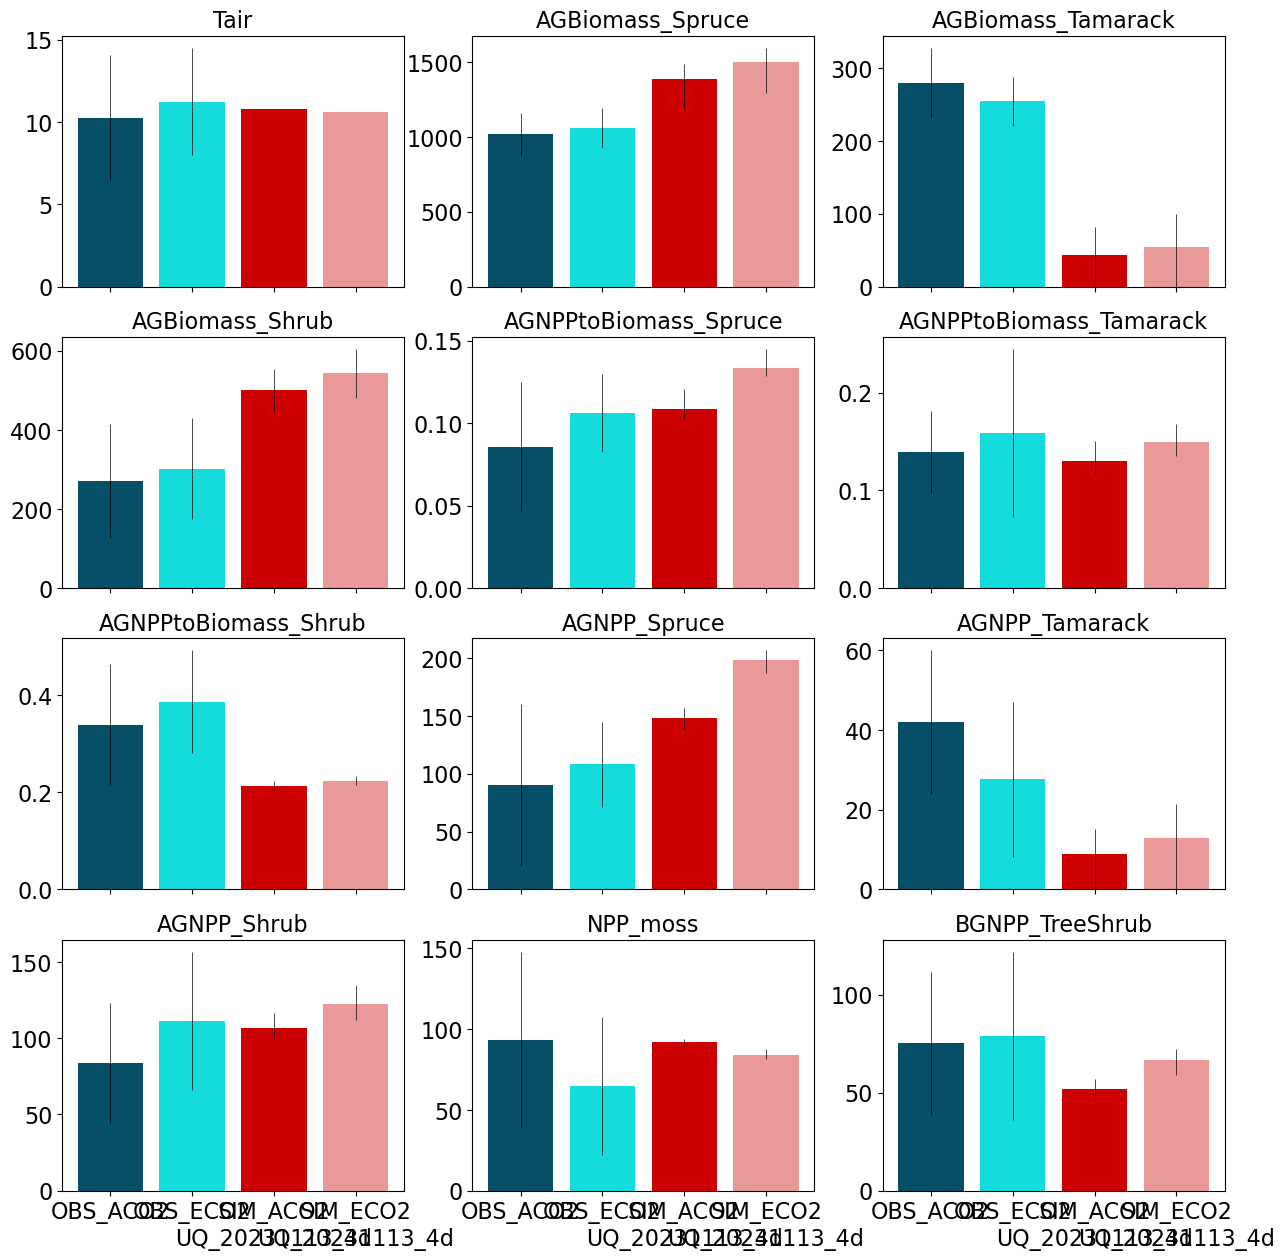

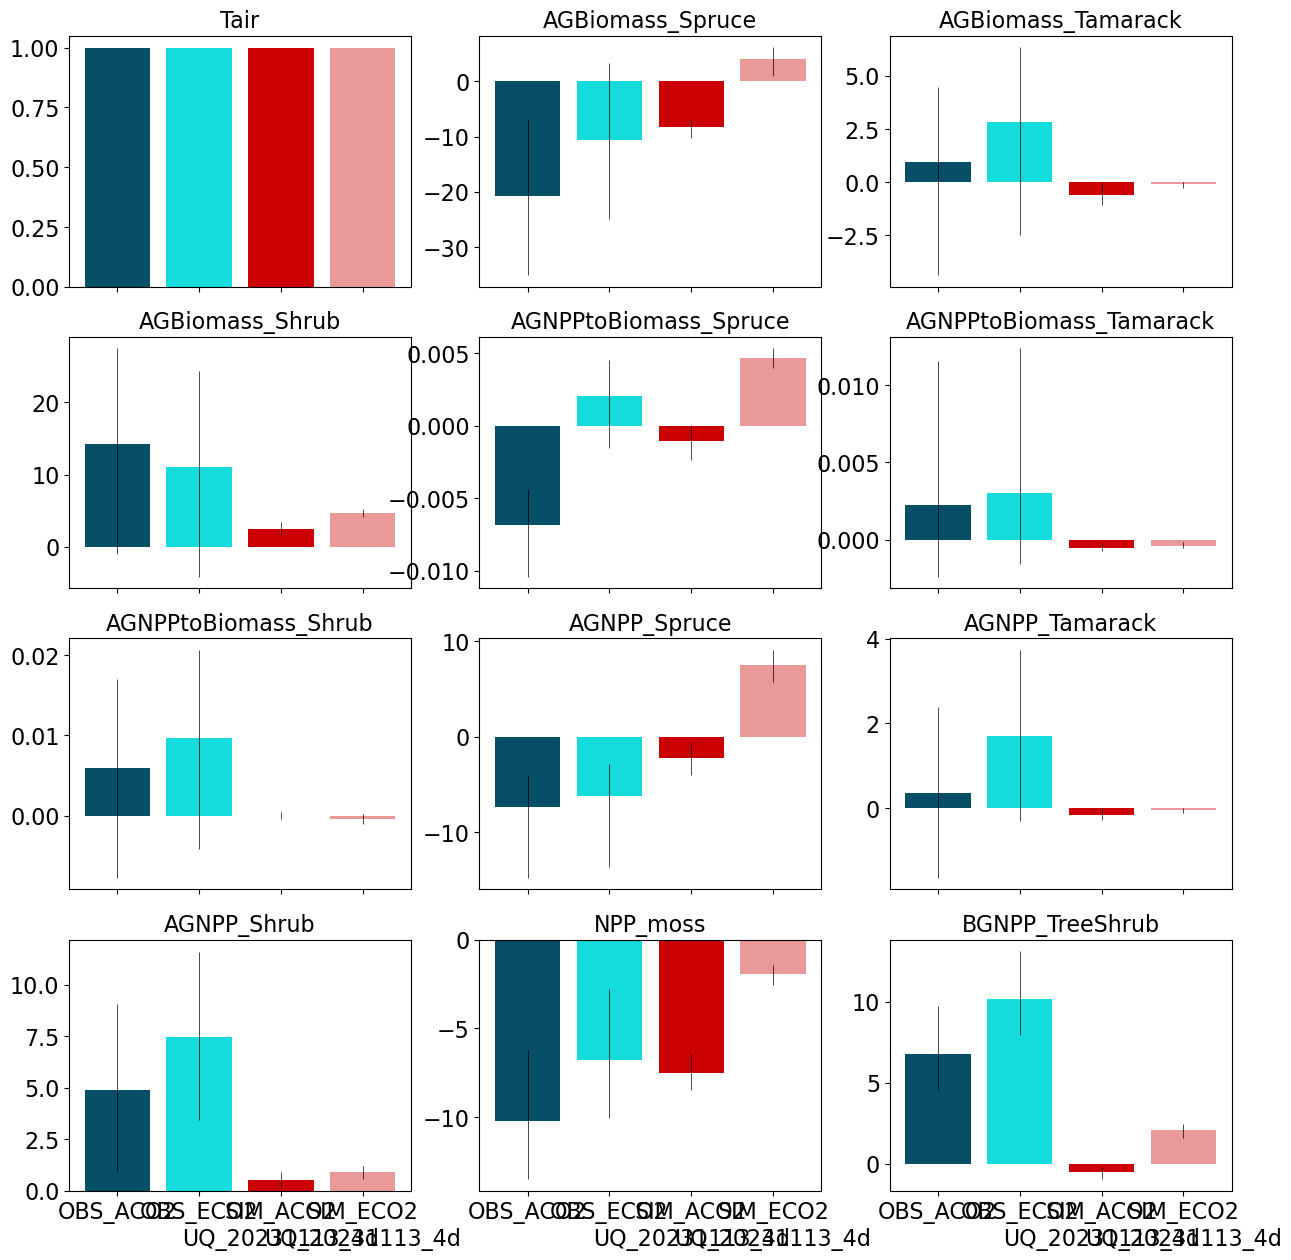

In [10]:
for quantity in ['mean', 'slope']:
    fig, axes = plt.subplots(4, 3, figsize = (15, 15), sharex = True, sharey = False)
    for i, ax in enumerate(axes.flat):
        if i >= len(VAR_LIST):
            ax.axis('off')
        else:
            varname = VAR_LIST[i]

            ax.bar([1, 2], collection_obs.loc[varname, quantity].values, 
                   color = ['#074e67', '#14dcdc'])
            ax.errorbar([1, 2], collection_obs.loc[varname, quantity].values, 
                        collection_obs.loc[varname, f'{quantity}_std'].values, 
                        ecolor = 'k', lw = 0, elinewidth = 0.5)
            ax.set_title(varname)

            if quantity == 'mean':
                k = 0
            else:
                k = 2

            for j, prefix in enumerate(prefix_list):
                temp = np.around(np.nanmean(collection_sim[prefix][:, i, :, k], axis = 0), 6)
                temp_q5 = np.around(np.nanpercentile(collection_sim[prefix][:, i, :, k], 5, axis = 0), 6)
                temp_q95 = np.around(np.nanpercentile(collection_sim[prefix][:, i, :, k], 95, axis = 0), 6)

                ax.bar([3+j*2, 4+j*2], temp, color = ['#cc0000', '#ea9999'])
                ax.errorbar([3+j*2, 4+j*2], temp, [temp - temp_q5, temp_q95 - temp], 
                            ecolor = 'k', lw = 0, elinewidth = 0.5)

        if i >= 5:
            ax.set_xticks(range(1, 3 + 2 * len(prefix_list)))
            ax.set_xticklabels(['OBS_ACO2', 'OBS_ECO2'] + [f'{a}\n{prefix}' for prefix in prefix_list for a in  ['SIM_ACO2', 'SIM_ECO2']])

## Just display the ANPP results

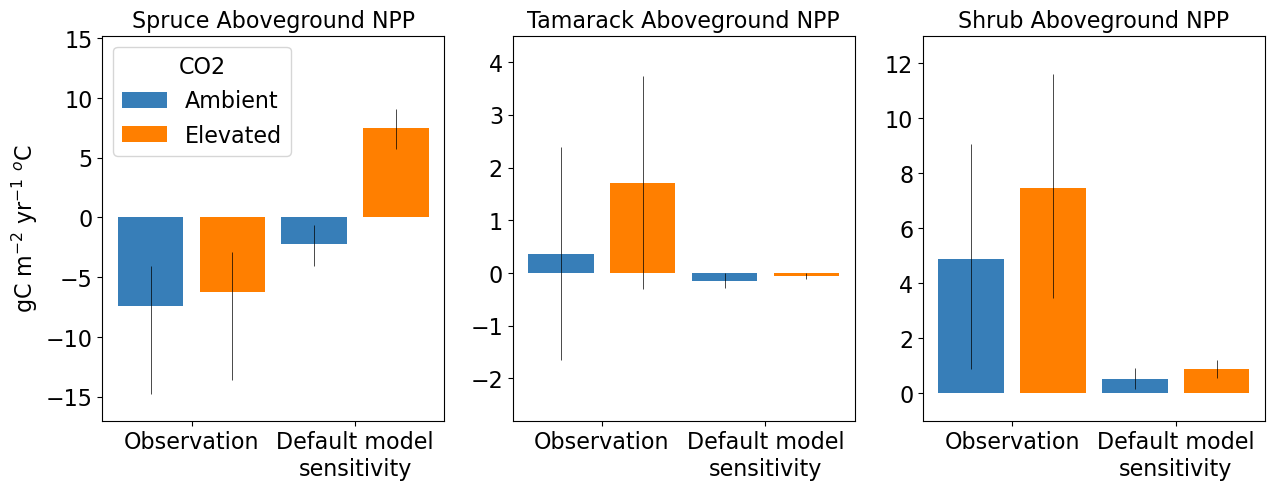

In [12]:
quantity = 'slope'

fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = False)
count = 0
for i, varname in enumerate(VAR_LIST):
    if not varname in ['AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub']:
        continue

    ax = axes.flat[count]

    h = ax.bar([1, 2], collection_obs.loc[varname, quantity].values, 
            color = ['#377eb8','#ff7f00'])
    ax.errorbar([1, 2], collection_obs.loc[varname, quantity].values, 
                collection_obs.loc[varname, f'{quantity}_std'].values, 
                ecolor = 'k', lw = 0, elinewidth = 0.5)
    ax.set_title(varname)

    if quantity == 'mean':
        k = 0
    else:
        k = 2

    for j, prefix in enumerate(prefix_list):
        temp = np.around(np.nanmean(collection_sim[prefix][:, i, :, k], axis = 0), 6)
        temp_q5 = np.around(np.nanpercentile(collection_sim[prefix][:, i, :, k], 5, axis = 0), 6)
        temp_q95 = np.around(np.nanpercentile(collection_sim[prefix][:, i, :, k], 95, axis = 0), 6)

        ax.bar([3+j*2, 4+j*2], temp, color = ['#377eb8','#ff7f00'])
        ax.errorbar([3+j*2, 4+j*2], temp, [temp - temp_q5, temp_q95 - temp], 
                    ecolor = 'k', lw = 0, elinewidth = 0.5)


    ax.set_xticks(np.arange(1.5, 3 + 2 * len(prefix_list), 2))
    ax.set_xticklabels(['Observation', 'Default model\nsensitivity'])
    if count == 0:
        ax.legend(h, ['Ambient', 'Elevated'], title = 'CO2', loc = 'upper left')
        ax.set_ylabel('gC m$^{-2}$ yr$^{-1}$ $^o$C')
    else:
        ax.set_ylabel('')

    if count == 0:
        ax.set_ylim([-17, 15.2])
    elif count == 1:
        ax.set_ylim([-2.8, 4.5])
    else:
        ax.set_ylim([-1, 13])
    pft = varname.split('_')[-1]
    ax.set_title(f'{pft} Aboveground NPP')

    count = count + 1